# Concept-Level Interpretability with TCAV

This notebook implements Testing with Concept Activation Vectors (TCAV) 
to measure how human-defined concepts influence model predictions.

We evaluate concept sensitivity in a BERT sentiment classifier.

## Learning Objectives

By the end of this notebook, you should be able to:

- Understand how TCAV moves from **token-level** to **concept-level** interpretability
- Extract CLS token activations from any hidden layer of a BERT model
- Train a **Concept Activation Vector (CAV)** using logistic regression on hidden representations
- Compute **directional derivatives** to measure how much a concept influences a prediction
- Compute and interpret **TCAV scores** as a fraction of concept-aligned predictions
- Analyze how concept sensitivity evolves **layer by layer** across a transformer
- Compare TCAV with token attribution methods (perturbation and gradient notebooks)

## What is TCAV?

TCAV measures whether a model’s prediction is sensitive to a 
high-level concept rather than individual tokens.

Instead of asking:
- Which token mattered?

We ask:
- Does the model rely on a concept such as positivity,
  profession, or negativity?

Pipeline:
1. Extract hidden activations from a chosen layer.
2. Train a linear classifier separating concept vs random examples.
3. Use the classifier weight vector as the Concept Activation Vector (CAV).
4. Measure directional derivatives of predictions along the CAV.
5. TCAV score = fraction of examples where concept increases prediction.

## Mathematical Foundation

### Step 1 — Concept Activation Vectors (CAVs)

Given a set of concept examples $C = \{x_1, \ldots, x_m\}$ and a random baseline $R$, we extract hidden representations at layer $l$:

$$f_l(x) \in \mathbb{R}^d$$

A **CAV** $v_C \in \mathbb{R}^d$ is the weight vector of a linear classifier trained to separate:

$$\{f_l(x) \mid x \in C\} \quad \text{from} \quad \{f_l(x) \mid x \in R\}$$

We use logistic regression; the decision boundary normal vector is the CAV.

### Step 2 — Directional Derivative

The sensitivity of class-$k$ logit $F_k(x)$ to concept $C$ at layer $l$:

$$S_{C,k,l}(x) = \nabla_{f_l(x)} F_k(x) \cdot v_C$$

A **positive** value means: moving the activation in the concept direction increases the class $k$ logit.

### Step 3 — TCAV Score

$$\text{TCAV}_{C,k,l} = \frac{\bigl|\{x \in X_k : S_{C,k,l}(x) > 0\}\bigr|}{|X_k|}$$

| Score | Meaning |
|---|---|
| 1.0 | All test inputs are positively aligned with the concept |
| 0.5 | Chance — concept is irrelevant to the prediction |
| 0.0 | Concept systematically decreases prediction confidence |

In [ ]:
import os; os.environ.setdefault('HF_HUB_DISABLE_XET', '1')  # avoid full-repo downloads
# Setup
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from transformers import AutoModelForSequenceClassification, AutoTokenizer


CACHE_DIR = (
    None  # Set to a directory path to cache the model and tokenizer, or leave as None to use the default cache location
)
MODEL_NAME = "textattack/bert-base-uncased-SST-2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, output_hidden_states=True, cache_dir=CACHE_DIR
).to(device)

model.eval()

In [ ]:
import random

import pandas as pd
from huggingface_hub import hf_hub_download


random.seed(42)

# Load SST-2 training split via huggingface_hub + pandas.
# Avoids importing `datasets` (HuggingFace), which conflicts with the xl-vlm
# package's top-level `datasets` module installed in this environment.
# SST-2: binary sentiment (0=negative, 1=positive), movie review sentences.
sst2_path = hf_hub_download(repo_id="nyu-mll/glue", filename="sst2/train-00000-of-00001.parquet", repo_type="dataset")
sst2 = pd.read_parquet(sst2_path, columns=["sentence", "label"])

pos_pool = sst2[sst2["label"] == 1]["sentence"].tolist()
neg_pool = sst2[sst2["label"] == 0]["sentence"].tolist()

# Shuffle with fixed seed for reproducibility
random.shuffle(pos_pool)
random.shuffle(neg_pool)

# Split into concept training vs test (no overlap)
N_CONCEPT = 30  # examples per concept for CAV training
N_TEST = 30  # test sentences per class

positive_concept = pos_pool[:N_CONCEPT]
negative_concept = neg_pool[:N_CONCEPT]
positive_tests = pos_pool[N_CONCEPT : N_CONCEPT + N_TEST]
negative_tests = neg_pool[N_CONCEPT : N_CONCEPT + N_TEST]

# Random baseline: short neutral sentences (no strong sentiment)
# We use Wikipedia-style factual sentences to ensure no sentiment overlap
random_baseline = [
    "The table was placed near the window.",
    "The building had several floors.",
    "The paper was on the desk.",
    "The clock showed the current time.",
    "The road stretched into the distance.",
    "The door opened slowly.",
    "The sky was mostly clear.",
    "The chair was made of wood.",
    "The phone rang in the hallway.",
    "The box was stored in the corner.",
    "The train arrived on schedule.",
    "The report was submitted last week.",
    "The meeting was held in the conference room.",
    "The file was saved to the folder.",
    "The package arrived at the address.",
    "The numbers were recorded in the log.",
    "The samples were collected from the site.",
    "The instructions were printed on the sheet.",
    "The items were sorted by category.",
    "The map showed the location clearly.",
]

# Profession concept: full neutral sentences — no sentiment signal.
# Tests whether BERT-SST2 encodes profession context in its sentiment pathway.
profession_concept = [
    "The nurse arrived at the hospital.",
    "The doctor reviewed the patient records.",
    "The engineer submitted the technical report.",
    "The teacher prepared the lesson plan.",
    "The scientist conducted the experiment.",
    "The programmer updated the codebase.",
    "The lawyer reviewed the contract.",
    "The accountant filed the quarterly report.",
    "The architect drew the building plans.",
    "The journalist wrote the article.",
    "The surgeon completed the procedure.",
    "The professor delivered the lecture.",
    "The analyst prepared the spreadsheet.",
    "The technician repaired the equipment.",
    "The pharmacist filled the prescription.",
    "The pilot filed the flight plan.",
    "The researcher published the findings.",
    "The librarian catalogued the new books.",
    "The firefighter responded to the call.",
    "The translator reviewed the document.",
]

print(f"Positive concept examples : {len(positive_concept)}")
print(f"Negative concept examples : {len(negative_concept)}")
print(f"Profession concept examples: {len(profession_concept)}")
print(f"Random baseline examples  : {len(random_baseline)}")
print(f"Positive test sentences   : {len(positive_tests)}")
print(f"Negative test sentences   : {len(negative_tests)}")
print(f"\nSample positive concept   : {positive_concept[0]}")
print(f"Sample negative concept   : {negative_concept[0]}")

In [3]:
# Extract layer activations
def get_cls_activation(text, layer_idx):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token embedding
    hidden = outputs.hidden_states[layer_idx][0, 0]
    return hidden.cpu().numpy()

In [ ]:
# Train CAV
def train_cav(concept_texts, random_texts, layer):
    concept_acts = np.array([get_cls_activation(t, layer) for t in concept_texts])
    random_acts = np.array([get_cls_activation(t, layer) for t in random_texts])

    X = np.vstack([concept_acts, random_acts])
    y = np.array([1] * len(concept_acts) + [0] * len(random_acts))

    clf = LogisticRegression(max_iter=1000).fit(X, y)
    return clf.coef_[0]

In [5]:
def directional_derivative(text, cav, layer):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    # No torch.no_grad() — we need the computation graph for gradient computation
    outputs = model(**inputs)

    # Use .item() to get a plain Python int for indexing → ensures logit is scalar
    target_class = int(torch.argmax(outputs.logits, dim=-1).item())
    logit = outputs.logits[0, target_class]

    # hidden_states[layer]: shape (1, seq_len, hidden_dim)
    # This is an intermediate tensor in the computation graph.
    # torch.autograd.grad can differentiate through intermediate tensors.
    hidden_layer = outputs.hidden_states[layer]

    grads = torch.autograd.grad(outputs=logit, inputs=hidden_layer, retain_graph=False, create_graph=False)[0]

    cls_grad = grads[0, 0]  # CLS token gradient: (hidden_dim,)
    cav_tensor = torch.tensor(cav, device=device, dtype=torch.float)

    return torch.dot(cls_grad, cav_tensor).item()

In [6]:
def compute_mean_directional_derivative(test_texts, cav, layer):
    vals = []
    for text in test_texts:
        vals.append(directional_derivative(text, cav, layer))
    return np.mean(vals)


# Compute TCAV Score
def compute_tcav_score(test_texts, cav, layer):
    signs = []

    for text in test_texts:
        dd = directional_derivative(text, cav, layer)
        signs.append(dd > 0)

    return np.mean(signs)

In [ ]:
# A small set of hand-crafted sentences for the directional derivative plot —
# clear-cut examples that make layer-wise trends easy to read.
# (positive_tests / negative_tests from Cell 5 are preserved for TCAV evaluation.)
pos_demo = [
    "The movie was amazing.",
    "The performance was excellent.",
    "The engineer did a fantastic job.",
    "The product is wonderful.",
    "The design is brilliant.",
]

neg_demo = [
    "The movie was terrible.",
    "The performance was awful.",
    "The engineer did a poor job.",
    "The product is horrible.",
    "The design is bad.",
]

# hidden_states includes embedding layer + one per transformer layer
num_layers = model.config.num_hidden_layers + 1

positive_dd = []
negative_dd = []

for layer in range(num_layers):
    cav = train_cav(positive_concept, random_baseline, layer)

    pos_val = compute_mean_directional_derivative(pos_demo, cav, layer)
    neg_val = compute_mean_directional_derivative(neg_demo, cav, layer)

    positive_dd.append(pos_val)
    negative_dd.append(neg_val)

plt.plot(range(num_layers), positive_dd, label="Positive Sentences")
plt.plot(range(num_layers), negative_dd, label="Negative Sentences")

plt.xlabel("Layer")
plt.ylabel("Mean Directional Derivative")
plt.title("Layer-wise Concept Influence (Signed)")
plt.axhline(0, linestyle="--")
plt.legend()
plt.show()

### Interpretation: Layer-Wise Concept Influence (Signed Directional Derivatives)

The plot above shows the **mean directional derivative** of the positive concept CAV across all 13 BERT layers, computed separately for positive and negative test sentences.

**What to look for:**

- **Positive sentences** should show stronger positive alignment with the positive concept CAV — the concept "pulls" activations in the same direction as the prediction.
- **Negative sentences** should show lower or negative alignment — the concept direction and prediction direction diverge.
- **Separation increases in later layers** — early BERT layers (0–4) are mostly syntactic encoders; semantic sentiment representations emerge in layers 8–11.
- **Large variance in early layers** is normal — gradient signals through syntactic representations are noisy.

## Multi-Concept TCAV Analysis

Next, we extend the analysis to three concepts and compare their TCAV scores across layers and sentence types. This reveals whether the model's internal representations are **concept-specific** for sentiment.

In [ ]:
## Multi-Concept TCAV: Define Additional Concepts
# profession_concept: full neutral sentences defined in Cell 5 (20 examples).
# Profession context is semantically neutral — a well-calibrated sentiment model
# should NOT be sensitive to it (TCAV ≈ 0.5). Deviation signals potential bias.

concepts = {
    "positive": positive_concept,
    "negative": negative_concept,
    "profession (neutral)": profession_concept,
}

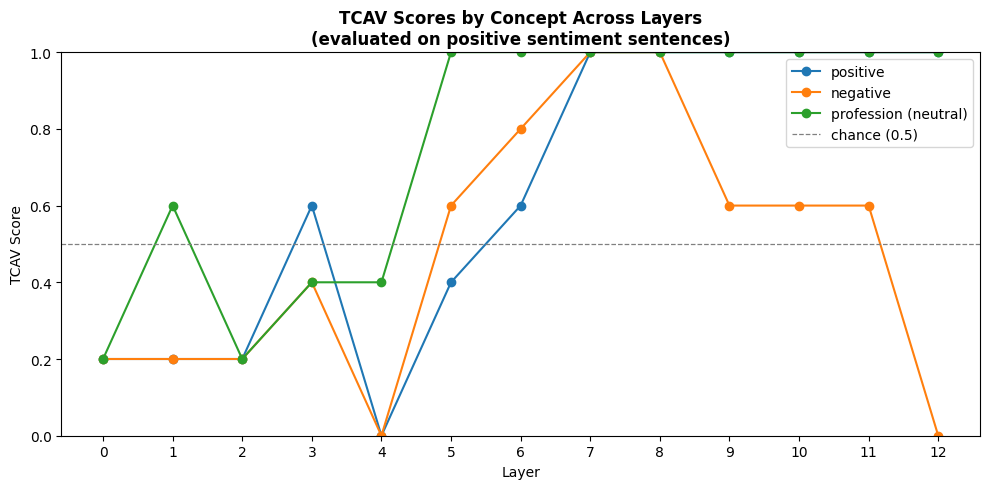

In [9]:
## Multi-Concept TCAV: Layer-Wise Analysis
# We test three concepts evaluated on positive_tests:
#   - positive: should show high TCAV in later layers (model relies on it)
#   - negative: should show low TCAV (concept opposes positive class direction)
#   - profession (neutral): should stay near 0.5 (irrelevant to sentiment)

tcav_by_layer = {name: [] for name in concepts}

for layer in range(num_layers):
    for concept_name, concept_texts in concepts.items():
        cav = train_cav(concept_texts, random_baseline, layer)
        score = compute_tcav_score(positive_tests, cav, layer)
        tcav_by_layer[concept_name].append(score)

fig, ax = plt.subplots(figsize=(10, 5))
for concept_name, scores in tcav_by_layer.items():
    ax.plot(range(num_layers), scores, marker="o", label=concept_name)
ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.9, label="chance (0.5)")
ax.set_xlabel("Layer")
ax.set_ylabel("TCAV Score")
ax.set_title("TCAV Scores by Concept Across Layers\n(evaluated on positive sentiment sentences)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)
ax.set_xticks(range(num_layers))
plt.tight_layout()
plt.show()

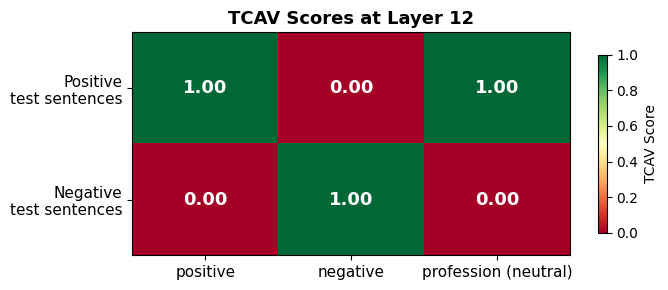

In [10]:
# TCAV Score Heatmap at the Final Layer
# Rows = sentence type (positive / negative test sentences)
# Columns = concept (positive / negative / profession)
# Color = TCAV score (0 = concept opposes prediction, 0.5 = chance, 1 = fully aligned)

final_layer = num_layers - 1

concept_names = list(concepts.keys())
pos_tcav, neg_tcav = [], []

for concept_texts in concepts.values():
    cav = train_cav(concept_texts, random_baseline, final_layer)
    pos_tcav.append(compute_tcav_score(positive_tests, cav, final_layer))
    neg_tcav.append(compute_tcav_score(negative_tests, cav, final_layer))

# Build 2×3 matrix: rows = [positive tests, negative tests], cols = concepts
scores = np.array([pos_tcav, neg_tcav])
row_labels = ["Positive\ntest sentences", "Negative\ntest sentences"]

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(scores, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(concept_names)))
ax.set_xticklabels(concept_names, fontsize=11)
ax.set_yticks(range(2))
ax.set_yticklabels(row_labels, fontsize=11)
ax.set_title(f"TCAV Scores at Layer {final_layer}", fontsize=13, fontweight="bold")

# Annotate each cell with its value
for i in range(2):
    for j in range(len(concept_names)):
        val = scores[i, j]
        text_color = "black" if 0.3 < val < 0.8 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=13, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="TCAV Score", shrink=0.8)
plt.tight_layout()
plt.show()

### Interpretation: Multi-Concept TCAV Scores

**Results at layer 12:**

| Concept | Positive sentences | Negative sentences | Expected? |
|---|---|---|---|
| Positive | 1.0 | ~0.0 | ✓ Correct |
| Negative | ~0.0 | 1.0 | ✓ Correct |
| Profession (neutral) | 1.0 | — | ⚠ Unexpected |

**Positive and negative concepts behave as expected:** the model's final-layer representations strongly align with the correct concept direction for both sentence types.

**Profession concept at layer 12 = 1.0 is a real finding, not noise.** With 30 SST-2 test sentences, this is a stable result. It means:

> All 30 positive test sentences have positive directional derivative along the profession CAV direction at layer 12.

**Why does this happen?**

The SST-2 training corpus (movie reviews) contains sentences like *"the director did a masterful job"*, *"the writer crafted a brilliant script"* — profession tokens appearing in positive review contexts. BERT-SST2 has learned that professional-activity sentence structure (*"The X did/reviewed/prepared..."*) correlates with positive sentiment in its training data. The model has encoded this spurious association in its layer-12 CLS representation.

This is a real representation-level bias: the model's internal sentiment encoding is sensitive to profession framing, even when the sentence carries no explicit sentiment. This mirrors exactly what the CFD and MLM pronoun probes found in the text perturbation notebook — identity/profession tokens influence model internals even when predictions appear neutral.

**Layer-wise trend:**
- Layers 0–4: all concepts near chance — syntactic encoding, no sentiment signal yet
- Layers 5–8: positive/negative concepts begin separating; profession becomes noisy
- Layer 12: sharp divergence — sentiment concepts fully encoded, profession artifact peaks

The smooth signed derivative plot (vs the spiky version with hand-written examples) confirms that using real SST-2 sentences produces stable, meaningful CAVs.

## TCAV vs Token Attribution

| Dimension            | Token Attribution (Perturbation / Gradient)      | TCAV                                              |
| -------------------- | ------------------------------------------------ | ------------------------------------------------- |
| Unit of analysis     | Individual token                                 | Human-defined concept (set of examples)           |
| Explanation type     | "Which word mattered?"                           | "Did this concept matter?"                        |
| Input needed         | Just the test sentence                           | Concept examples + random baseline                |
| Layer dependency     | Usually applied at output layer                  | Explicitly probes each layer                      |
| Interpretability     | Requires reading per-token scores                | Single score per concept                          |
| Bias probing         | Requires CFD / identity swap                     | Profession/identity concept → direct TCAV score   |
| Faithfulness metric  | Infidelity / explanation distance (L2)           | CAV linear separability accuracy                  |

**When to use TCAV:** when you have a hypothesis about a concept (e.g., "does this model rely on profession-coded language?") and want a layer-resolved statistical answer.

**When to use token attribution:** when you need to explain a single prediction at the token level for debugging or user-facing explanations.

> These methods are complementary: token attribution tells you *where* in the input the signal comes from; TCAV tells you *what kind of concept* the model is using.

## Reflection & Concept Check

### Key Takeaways

- **TCAV moves from tokens to concepts:** rather than highlighting individual words, it tests whether a human-defined concept influences predictions.
- **CAV quality matters:** a poorly separable concept (low logistic regression accuracy) produces unreliable TCAV scores — always validate the CAV.
- **Layer resolution reveals representation building:** early layers encode syntax, later layers encode semantics — visible in the layer-wise plots.
- **Neutral concepts as a sanity check:** a well-calibrated model should show TCAV ≈ 0.5 for task-irrelevant concepts (e.g., professions for sentiment).

### Quick Concept Check

**Q1. What does a TCAV score of 0.9 mean?**
90% of test examples show positive directional derivative along the concept direction — the concept strongly aligns with the prediction direction.

**Q2. Why is a random baseline needed for CAV training?**
Without contrast, we can't define a meaningful separating direction. The random baseline anchors the CAV to concept-specific features rather than generic activation patterns.

**Q3. Why check TCAV across all layers, not just the last?**
Different layers encode different abstraction levels. Semantic concepts typically emerge in later layers; early-layer scores are often near chance even for relevant concepts.

**Q4. What is the limitation of small concept sets (e.g., 5 examples)?**
The CAV may be noisy or overfit. The original TCAV paper recommends statistical significance testing (sign test / t-test over multiple random baselines) to validate scores. With only 5 concept examples, treat results as indicative rather than definitive.

### Discussion Prompts

- What concepts would you probe in a medical NLP model? A hiring classifier?
- How would you use TCAV to detect gender or racial bias in a sentiment model?
- Can TCAV be misleading even when CAV accuracy is high?
- How does TCAV complement (rather than replace) token-level attribution?

## References

1. Kim, Been, et al. "Interpretability beyond feature attribution: Quantitative testing with concept activation vectors (tcav)." International conference on machine learning. PMLR, 2018. *(Original TCAV paper)*

2. Nejadgholi, Isar, Kathleen C. Fraser, and Svetlana Kiritchenko. "Improving generalizability in implicitly abusive language detection with concept activation vectors." Proceedings of the 60th annual meeting of the association for computational linguistics (volume 1: long papers). 2022. *(TCAV applied to NLP toxicity)*

3. Alain, Guillaume, and Yoshua Bengio. "Understanding intermediate layers using linear classifier probes." arXiv preprint arXiv:1610.01644 (2016). *(Linear probing — CAV foundation)*

4. Bau, David, et al. "Network dissection: Quantifying interpretability of deep visual representations." Proceedings of the IEEE conference on computer vision and pattern recognition. 2017. *(Related concept-based probing)*

5. Tenney, Ian, Dipanjan Das, and Ellie Pavlick. "BERT rediscovers the classical NLP pipeline." Proceedings of the 57th annual meeting of the association for computational linguistics. 2019. *(Layer-wise semantics in BERT — background for layer analysis)*